## Clase 08

#### Simulación de Procesos Financieros

José Armando Melchor Soto
 | 14/09/2026

---

### Libraries 

In [134]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde

---

### Functions

In [135]:
def simulate_St(S0, r, sigma, T):
    """
    Simulates the underlying asset price at maturity using the Geometric Brownian Motion model.
    Parameters
    ----------
    S0 : float
        Initial price of the underlying asset.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    Returns
    -------
    float
        Simulated asset price at maturity.
    """
    Z = np.random.normal(0, 1)
    St = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    return St


def simulate_trajectory(S0, r, sigma, T, n):
    """
    Simulates one complete price trajectory using Geometric Brownian Motion.
    Parameters
    ----------
    S0 : float
        Initial price of the underlying asset.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    n : int
        Number of time steps.
    Returns
    -------
    np.ndarray
        Simulated price trajectory.
    """
    dt = T / n
    S = np.zeros(n + 1)
    S[0] = S0
    for i in range(n):
        Z = np.random.normal(0, 1)
        S[i + 1] = S[i] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return S


def simulate_trajectories(S0, r, sigma, T, n, N):
    """
    Simulates multiple price trajectories using Geometric Brownian Motion.
    Parameters
    ----------
    S0 : float
        Initial price of the underlying asset.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    n : int
        Number of time steps per trajectory.
    N : int
        Number of trajectories to simulate.
    Returns
    -------
    np.ndarray
        Matrix containing all simulated trajectories.
    """
    trajectories = np.zeros((N, n + 1))
    for i in range(N):
        trajectories[i, :] = simulate_trajectory(S0, r, sigma, T, n)
    return trajectories


def plot_trajectories(trajectories, T, K=None, S=None, IC=None):
    """
    Plots simulated Geometric Brownian Motion trajectories.
    Parameters
    ----------
    trajectories : np.ndarray
        Matrix containing simulated trajectories.
    T : float
        Time to maturity in years.
    K : float, optional
        Strike price to display.
    S : float, optional
        Reference asset price to display.
    IC : float, optional
        Confidence interval level to display.
    """
    N, n_plus_one = trajectories.shape
    mean = np.mean(trajectories, axis=0)
    t = np.linspace(0, T, n_plus_one)
    P2_5 = np.percentile(trajectories, 2.5, axis=0)
    P97_5 = np.percentile(trajectories, 97.5, axis=0)
    plt.figure(figsize=(10, 6))
    for i in range(min(20, N)):
        plt.plot(t, trajectories[i, :], alpha=0.3)
    plt.plot(t, mean, linewidth=2, label="Media")
    plt.fill_between(t, P2_5, P97_5, alpha=0.2, label="95% de confianza")
    if K is not None:
        plt.axhline(K, linestyle="--", label=f"K = {K}")
    if S is not None:
        plt.axhline(S, linestyle="--", label=f"S = {S}")
    if IC is not None:
        plt.axhline(IC, linestyle="--", label=f"IC = {IC}")
    plt.xlabel("Tiempo (años)")
    plt.ylabel("Precio")
    plt.title("Simulación de S(t) con 95% de confianza")
    plt.legend()
    plt.grid()
    plt.show()
   
    

def american_payoff(St, K, option_type="call"):
    """
    Calculates the payoff of an American option.
    Parameters
    ----------
    St : np.ndarray
        Simulated asset prices over time.
    K : float
        Strike price of the option.
    option_type : str
        Type of option: "call" or "put".
    Returns
    -------
    float
        Maximum payoff of the American option.
    """
    if option_type == "call":
        return np.max(np.maximum(St - K, 0))
    elif option_type == "put":
        return np.max(np.maximum(K - St, 0))
    else:
        raise ValueError("option_type must be 'call' or 'put'")


def asiatic_payoff(St, K, option_type="call"):
    """
    Calculates the payoff of an Asian option.
    Parameters
    ----------
    St : np.ndarray
        Simulated asset prices over time.
    K : float
        Strike price of the option.
    option_type : str
        Type of option: "call" or "put".
    Returns
    -------
    float
        Payoff of the Asian option.
    """
    average_price = np.mean(St)
    if option_type == "call":
        return max(average_price - K, 0)
    elif option_type == "put":
        return max(K - average_price, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


def european_payoff(St, K, option_type="call"):
    """
    Calculates the payoff of a European option.
    Parameters
    ----------
    St : float
        Simulated asset price at maturity.
    K : float
        Strike price of the option.
    option_type : str
        Type of option: "call" or "put".
    Returns
    -------
    float
        Payoff of the European option.
    """
    if option_type == "call":
        return max(St - K, 0)
    elif option_type == "put":
        return max(K - St, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


def table_payoffs(trajectories, K, r, T):
    """
    Creates a DataFrame containing the present value of the payoffs of American, Asian, and European options.
    Parameters
    ----------
    trajectories : np.ndarray
        Matrix containing simulated trajectories.
    K : float
        Strike price of the options.
    r : float
        Risk-free interest rate.
    T : float
        Time to maturity in years.
    Returns
    -------
    pd.DataFrame
        DataFrame containing the present value of each option payoff.
    """
    discount_factor = np.exp(-r * T)
    payoffs = {
        "American Call": [american_payoff(St, K, "call") * discount_factor for St in trajectories],
        "American Put": [american_payoff(St, K, "put") * discount_factor for St in trajectories],
        "Asian Call": [asiatic_payoff(St, K, "call") * discount_factor for St in trajectories],
        "Asian Put": [asiatic_payoff(St, K, "put") * discount_factor for St in trajectories],
        "European Call": [european_payoff(St[-1], K, "call") * discount_factor for St in trajectories],
        "European Put": [european_payoff(St[-1], K, "put") * discount_factor for St in trajectories]
    }
    return pd.DataFrame(payoffs)


def summary_payoffs(trajectories, K, r, T):
    """
    Creates a summary table with descriptive statistics for each option present value.
    Parameters
    ----------
    trajectories : np.ndarray
        Matrix containing simulated trajectories.
    K : float
        Strike price of the options.
    r : float
        Risk-free interest rate.
    T : float
        Time to maturity in years.
    Returns
    -------
    pd.DataFrame
        DataFrame containing descriptive statistics for each option.
    """
    payoffs_df = table_payoffs(trajectories, K, r, T)
    return payoffs_df.describe().T


def density_call_payoffs(trajectories, K, r, T):
    """
    Plots the density of the present values of American, Asian, and European call options.
    Parameters
    ----------
    trajectories : np.ndarray
        Matrix containing simulated trajectories.
    K : float
        Strike price of the options.
    r : float
        Risk-free interest rate.
    T : float
        Time to maturity in years.
    """
    payoffs_df = table_payoffs(trajectories, K, r, T)
    plt.figure(figsize=(10, 6))
    sns.kdeplot(payoffs_df["Asian Call"], linewidth=2, label="Asian Call", color = "green")
    sns.kdeplot(payoffs_df["European Call"], linewidth=2, label="European Call", color = "red")
    plt.xlabel("Present Value")
    plt.ylabel("Density")
    plt.title("Call Option Present Value Density")
    plt.legend()
    plt.grid()
    plt.show()

"""
def density_put_payoffs(trajectories, K, r, T):

    trajectories : np.ndarray
        Matrix containing simulated trajectories.
    K : float
        Strike price of the options.
    r : float
        Risk-free interest rate.
    T : float
        Time to maturity in years.

    payoffs_df = table_payoffs(trajectories, K, r, T)
    plt.figure(figsize=(10, 6))
    sns.kdeplot(payoffs_df["Asian Put"], linewidth=2, label="Asian Put", color = "green")
    sns.kdeplot(payoffs_df["European Put"], linewidth=2, label="European Put", color = "red")
    plt.xlabel("Present Value")
    plt.ylabel("Density")
    plt.title("Put Option Present Value Density")
    plt.legend()
    plt.grid()
    plt.show()
"""

'\ndef density_put_payoffs(trajectories, K, r, T):\n\n    trajectories : np.ndarray\n        Matrix containing simulated trajectories.\n    K : float\n        Strike price of the options.\n    r : float\n        Risk-free interest rate.\n    T : float\n        Time to maturity in years.\n\n    payoffs_df = table_payoffs(trajectories, K, r, T)\n    plt.figure(figsize=(10, 6))\n    sns.kdeplot(payoffs_df["Asian Put"], linewidth=2, label="Asian Put", color = "green")\n    sns.kdeplot(payoffs_df["European Put"], linewidth=2, label="European Put", color = "red")\n    plt.xlabel("Present Value")\n    plt.ylabel("Density")\n    plt.title("Put Option Present Value Density")\n    plt.legend()\n    plt.grid()\n    plt.show()\n'



#### Párametros 

In [136]:
S0 = 100 # Initial price 
K = 110 # Strike price
r = 0.05 # Risk-free rate
sigma = 0.2 # Volatility
T = 1 # Time to maturity in years
n = 252 # Number of trading days in a year
N = 50
M = 1000 # Number of simulations

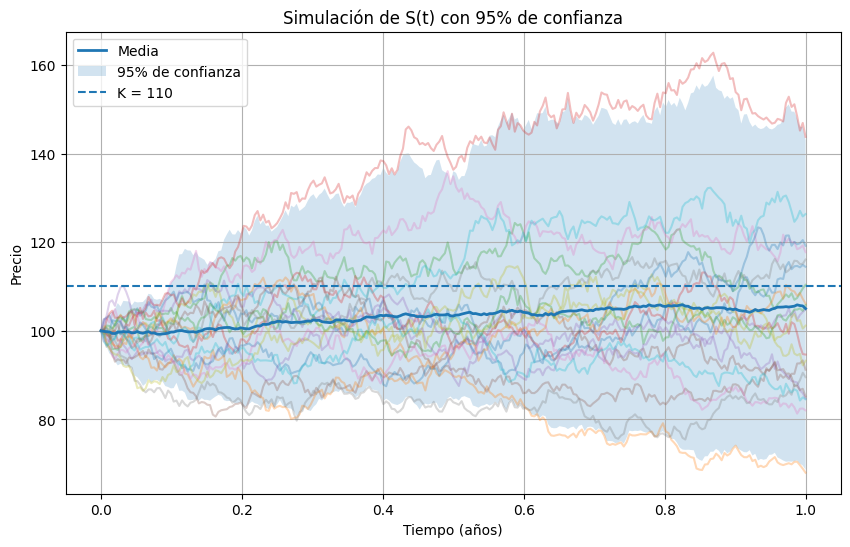

In [137]:
trajectories = simulate_trajectories(S0, r, sigma, T, n, N)

plot_trajectories(trajectories, T, K)

In [138]:
summary = summary_payoffs(trajectories, K, r, T)
display(summary)

,count,mean,std,min,25%,50%,75%,max
American Call,50.0,8.852022,14.442507,0.000000,0.000000,2.027850,11.638069,67.664264
American Put,50.0,20.791103,8.114645,9.512294,14.954608,20.241832,25.213227,44.822137
Asian Call,50.0,2.514093,6.359976,0.000000,0.000000,0.000000,0.000000,26.389078
Asian Put,50.0,9.074516,6.889144,0.000000,4.224771,9.340416,13.761321,29.160646
European Call,50.0,5.583666,12.132540,0.000000,0.000000,0.000000,4.029073,64.031076
European Put,50.0,10.322184,11.561757,0.000000,0.000000,5.703033,16.851278,41.338394


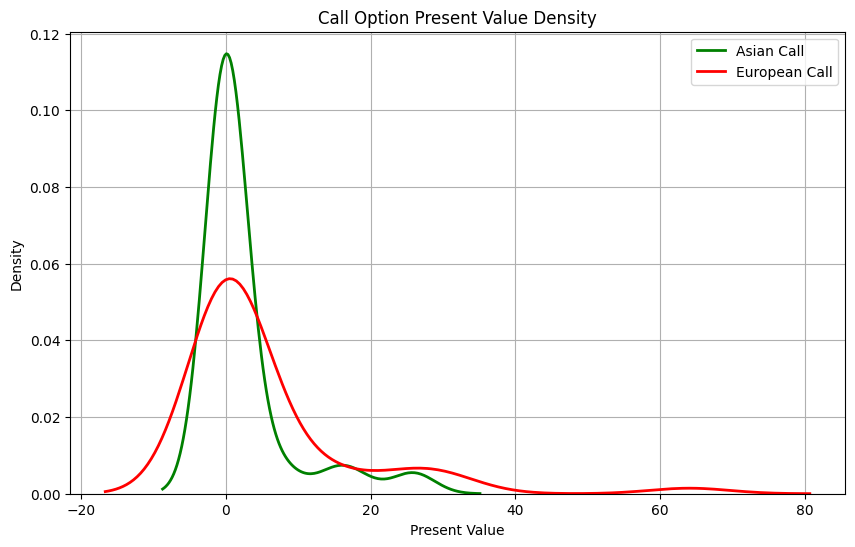

In [140]:
density_call_payoffs(trajectories, K, r, T)